# Laboratorio 2 

# Importacion de librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV, validation_curve, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Carga de datos

In [2]:
datos_lab = pd.read_csv('Datos_Lab_1.csv')
datos_test = pd.read_csv('Datos_Test_Lab_1.csv')
diccionario = pd.read_excel('Diccionario_de_datos.xlsx')


In [3]:
data = datos_lab.copy()

In [4]:
print(datos_lab.columns.tolist())

['fecha', 'presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'anio', 'dia_del_anio', 'estacion_anio', 'mes', 'sector_viento', 'temp_max_manana']


In [5]:
# 1. Copiar y limpiar nulos en la variable objetivo si existen
data = datos_lab.copy()
TARGET_COL = 'temp_max_manana'
data = data.dropna(subset=[TARGET_COL])

# 2. Definir columnas a excluir
cols_a_excluir = ['fecha', TARGET_COL]

# 3. Separar características generales (X) y objetivo (y)
X = data.drop(columns=[col for col in cols_a_excluir if col in data.columns])
y = data[TARGET_COL]

# 4. Dividir en train y test correctamente
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Identificar tipos de columnas automáticamente
columnas_numericas = X_train_full.select_dtypes(include=['int64', 'float64']).columns.tolist()
columnas_categoricas = X_train_full.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Variables numéricas detectadas: {len(columnas_numericas)}")
print(f"Variables categóricas detectadas: {columnas_categoricas}")

# 6. Pipeline para variables numéricas: primero imputa nulos y luego escala
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Rellena nulos con la mediana
    ('scaler', StandardScaler())
])

# 7. Preprocesador unificado
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), columnas_categoricas)
    ]
)

Variables numéricas detectadas: 22
Variables categóricas detectadas: ['estacion_anio', 'mes', 'sector_viento']


C:\Users\Usuario\AppData\Local\Temp\ipykernel_15660\2205101283.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = X_train_full.select_dtypes(include=['object', 'category']).columns.tolist()


## Regresion polinomial

In [6]:
pipe_poly = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)), # Usamos grado 2 por defecto para evitar explosión combinatoria
    ('regressor', LinearRegression())
])

param_grid_poly = {
    'poly__degree': [1, 2] # Explorar grado 1 y 2 (grado 3 con tantas variables puede ser muy pesado)
}

grid_poly = GridSearchCV(
    estimator=pipe_poly,
    param_grid=param_grid_poly,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    return_train_score=True
)
grid_poly.fit(X_train_full, y_train_full)
print("\n--- ACT 1: Mejor Regresión Polinomial ---")
print("Mejores Hiperparámetros:", grid_poly.best_params_)
print("RMSE Negativo en CV:", grid_poly.best_score_)


--- ACT 1: Mejor Regresión Polinomial ---
Mejores Hiperparámetros: {'poly__degree': 1}
RMSE Negativo en CV: -7.295279312133625


## Modelos Regularizados (Ridge y Lasso)

In [7]:
# Ridge Lineal
pipe_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', Ridge())
])
param_grid_ridge = {'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
grid_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1, return_train_score=True)
grid_ridge.fit(X_train_full, y_train_full)

# Lasso Lineal
pipe_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', Lasso(max_iter=20000))
])
param_grid_lasso = {'lasso__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
grid_lasso = GridSearchCV(pipe_lasso, param_grid_lasso, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1, return_train_score=True)
grid_lasso.fit(X_train_full, y_train_full)

print("\n--- ACT 3: Modelos Regularizados ---")
print("Mejor Ridge alpha:", grid_ridge.best_params_, "Score:", grid_ridge.best_score_)
print("Mejor Lasso alpha:", grid_lasso.best_params_, "Score:", grid_lasso.best_score_)


--- ACT 3: Modelos Regularizados ---
Mejor Ridge alpha: {'ridge__alpha': 10.0} Score: -7.001126725429309
Mejor Lasso alpha: {'lasso__alpha': 0.01} Score: -7.024930033752956


## Polinomial Regularizado

In [10]:
pipe_poly_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('ridge', Ridge())
])

param_grid_poly_ridge = {
    'poly__degree': [1, 2],
    'ridge__alpha': [0.1, 1.0, 10.0, 100.0]
}

grid_poly_ridge = GridSearchCV(
    estimator=pipe_poly_ridge,
    param_grid=param_grid_poly_ridge,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_poly_ridge.fit(X_train_full, y_train_full)
print("¡Entrenamiento de Polinomial Regularizado completado!")
print("Mejores Hiperparámetros:", grid_poly_ridge.best_params_)

¡Entrenamiento de Polinomial Regularizado completado!
Mejores Hiperparámetros: {'poly__degree': 2, 'ridge__alpha': 100.0}


## Comparativa y selección de nuevos modelos

In [11]:
modelos_candidatos = {
    "Polinomial Simple": grid_poly.best_estimator_,
    "Ridge Lineal": grid_ridge.best_estimator_,
    "Lasso Lineal": grid_lasso.best_estimator_,
    "Polinomial Regularizado (Ridge)": grid_poly_ridge.best_estimator_
}

resultados_comparativos = []

for nombre, modelo in modelos_candidatos.items():
    y_pred_test = modelo.predict(X_test)
    resultados_comparativos.append({
        "Modelo": nombre,
        "RMSE Test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "MAE Test": mean_absolute_error(y_test, y_pred_test),
        "R2 Test": r2_score(y_test, y_pred_test)
    })

df_resultados = pd.DataFrame(resultados_comparativos)
print("\n--- TABLA COMPARATIVA EN TEST ---")
print(df_resultados)

mejor_idx = df_resultados["RMSE Test"].idxmin()
mejor_nombre_modelo = df_resultados.loc[mejor_idx, "Modelo"]
best_model = modelos_candidatos[mejor_nombre_modelo]
print(f"\n>>> MEJOR MODELO SELECCIONADO: {mejor_nombre_modelo} <<<")


--- TABLA COMPARATIVA EN TEST ---
                            Modelo     RMSE Test     MAE Test       R2 Test
0                Polinomial Simple     26.434455     6.444391 -7.783105e+00
1                     Ridge Lineal     18.409505     5.972012 -3.259823e+00
2                     Lasso Lineal     21.905996     6.123928 -5.031612e+00
3  Polinomial Regularizado (Ridge)  38685.447514  1739.188808 -1.881060e+07

>>> MEJOR MODELO SELECCIONADO: Ridge Lineal <<<


## Intervalosd e confianza (Bootstraping en test)


--- INTERVALOS DE CONFIANZA AL 95% (Test Bootstrapping) ---
RMSE IC 95%: [ 6.25056184 30.50732425]
MAE IC 95%: [4.89771584 7.63889324]
R2 IC 95%: [-11.22969326   0.49412187]


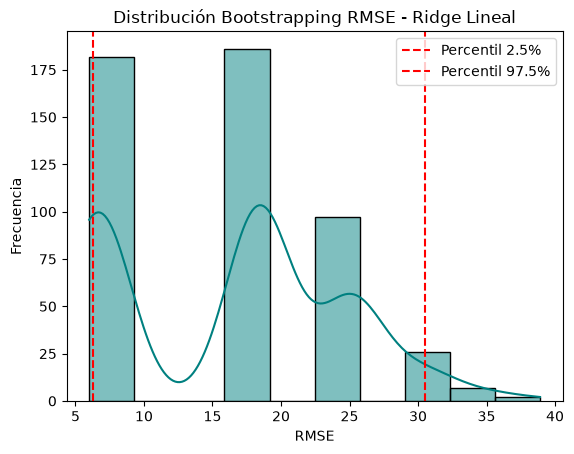

In [12]:
n_bootstraps = 500
rmse_boot, mae_boot, r2_boot = [], [], []
rng = np.random.RandomState(42)

for _ in range(n_bootstraps):
    indices = rng.randint(0, len(X_test), len(X_test))
    X_b = X_test.iloc[indices]
    y_b = y_test.iloc[indices]
    
    y_pred_b = best_model.predict(X_b)
    
    rmse_boot.append(np.sqrt(mean_squared_error(y_b, y_pred_b)))
    mae_boot.append(mean_absolute_error(y_b, y_pred_b))
    r2_boot.append(r2_score(y_b, y_pred_b))

print("\n--- INTERVALOS DE CONFIANZA AL 95% (Test Bootstrapping) ---")
print(f"RMSE IC 95%: {np.percentile(rmse_boot, [2.5, 97.5])}")
print(f"MAE IC 95%: {np.percentile(mae_boot, [2.5, 97.5])}")
print(f"R2 IC 95%: {np.percentile(r2_boot, [2.5, 97.5])}")

# Gráfica de distribución del RMSE en el bootstrapping
plt.figure()
sns.histplot(rmse_boot, kde=True, color='teal')
plt.axvline(np.percentile(rmse_boot, 2.5), color='red', linestyle='--', label='Percentil 2.5%')
plt.axvline(np.percentile(rmse_boot, 97.5), color='red', linestyle='--', label='Percentil 97.5%')
plt.title(f"Distribución Bootstrapping RMSE - {mejor_nombre_modelo}")
plt.xlabel("RMSE")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()